Script évaluant la spatial likelihood mapping des modèles ResNet, en comparant une version rétinotopique et une version cartésienne du réseau. L’objectif est d’analyser les zones de l’image où le modèle attribue la plus forte probabilité au label prédit. On teste :

    La génération de heatmaps de likelihood pour chaque image du dataset, identifiant les régions maximisant ou minimisant la probabilité du label correct.
    Les différences de comportement entre la version retinotopic et la version cartesian du réseau, afin de comprendre leur sensibilité respective à la structure spatiale des images.

Les résultats, sous forme de average confidence heatmaps, sont stockés dans des fichiers Parquet pour une analyse approfondie.

In [2]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.1.2+cu118
---------------------------------------------------------------------------------------------------
Welcome on Windows-10-10.0.19045-SP0
Random seed 1998 has been set.


In [3]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False
args.do_polar = False

## doing the computations

In [ ]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)
retino_grid = get_grid(args).unsqueeze(0).to(device)
print(args)

annotations = None
#for model_data_set_type in data_set_types:
for model_data_set_type in ['bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')

        
        for do_polar in [True, False]:
            sum_map = []
            do_polar = do_polar if model_data_set_type != 'raw' else False

            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_Imagenet_mean_map_test.parquet'
            print(df_filename)
            
            if os.path.isfile(df_filename):
                continue
            else:
                df_map = None
                
                print(50*'.')
                
                model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt' if model_data_set_type != 'raw' else None

                #model_filename = f"cached_data/2024-03-04_{model_name}_do_polar={do_polar}_do_rottrain=False.pt"
                
                model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
                
                if annotations is None:
                    annotations = get_annotation('csv')

                with torch.no_grad():
                    image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)
                    #for indice in tqdm(indices):
                        #indice = int(indice)
                        #images, label = image_datasets[indice]
                    
                    for i_image, (images, label) in tqdm(enumerate(image_datasets)):

                        image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                        
                        ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
                        
                        if ground_true.min() == 0.0:
                            
                            since = time.time()
                            

                            
                            images = images.to(device, non_blocking=True)

                            heat_map = model(images)
                            heat_map = torch.nn.functional.softmax(heat_map, dim=1)
                            proba_label = heat_map[:, label].reshape(args.resolution)
                            arg_max_prior = torch.argmax(proba_label)
                            position_prior = (arg_max_prior.item()//min(args.resolution), arg_max_prior.item()%min(args.resolution))
                            sum_map.append(collect_centered_map(args, proba_label, position_prior))
                            #sum_map.append(proba_label)


                mean_map = torch.stack(sum_map).nanmean(dim=0)  
                mean_map = np.array(mean_map.cpu())
                #fig, ax = plt.subplots(1, 1, figsize=(10, 10))
                #sns.heatmap(mean_map, linewidth = 0 , annot = False, cmap=cmap, vmin=0, vmax=1, cbar = False, alpha=.5, ax=ax)
                mean_map = mean_map.reshape(args.resolution[0]*args.resolution[1])
                df_map_ = pd.DataFrame({'ImageId':[image_name], 'mean_map': [mean_map]})
                df_map = store_pandas(df_map, df_map_)
               
            df_map.to_parquet(df_filename)   

In [4]:
def get_mean_map(model_data_set_type, model_name):

    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_Imagenet_mean_map_test.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    ret_map = np.array(df['mean_map'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_Imagenet_mean_map_test.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    cart_map = np.array(df['mean_map'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_Imagenet_mean_map.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    raw_map = np.array(df['mean_map'][0].reshape(args.resolution[0], args.resolution[1]))
    
    return raw_map, cart_map, ret_map

raw_map, cart_map, ret_map = get_mean_map('bbox', 'resnet101')

df_filename='cached_data/2024-05-24_bbox_resnet101_retino_Imagenet_mean_map_test.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_Imagenet_mean_map_test.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_Imagenet_mean_map.parquet'


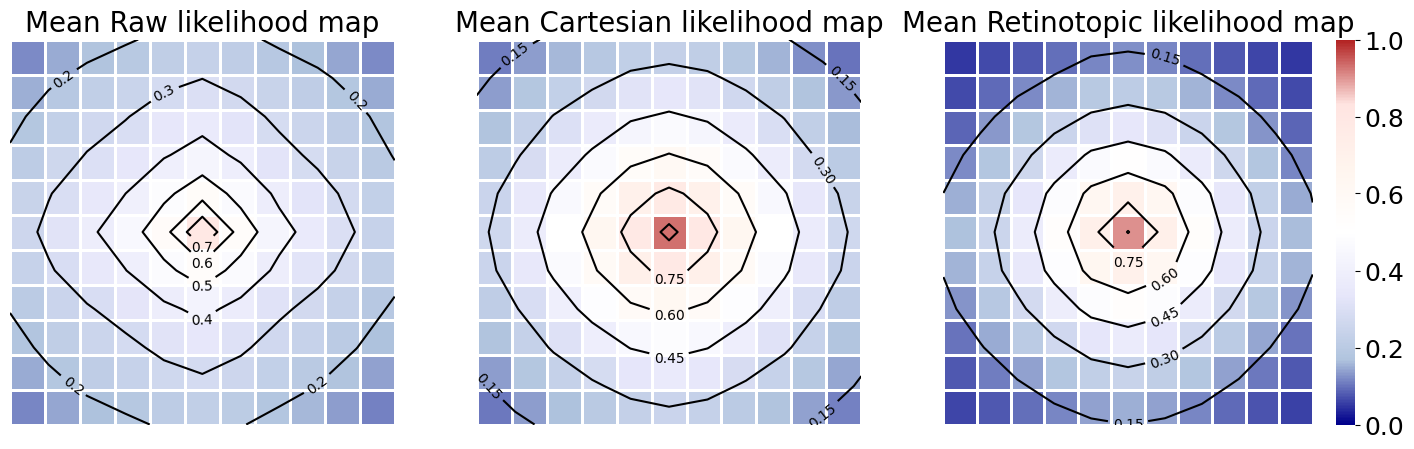

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])
i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']
for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model]
    title_mod = all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap=cmap, vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax,annot_kws={"fontsize":9})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'Mean {title_mod} likelihood map', size = 20)
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.imshow(result_map)

if False:
    to_save(fig, 'fig-mean_map_Imagenet_paper')

In [6]:
def get_odd_ratio(map1, map2, epsilon=1e-10):
    if map1.shape != map2.shape:
        print('Incompatible shape :(')
        return

    # Ensure probabilities are between 0 and 1 (not exactly 0 or 1)
    map1 = np.clip(map1, epsilon, 1 - epsilon)
    map2 = np.clip(map2, epsilon, 1 - epsilon)

    ones = np.ones(map1.shape)
    p1 = map1 / (ones - map1)  # odds for map1
    p2 = map2 / (ones - map2)  # odds for map2
    odd_ratio = p1 / p2

    return np.log(odd_ratio)


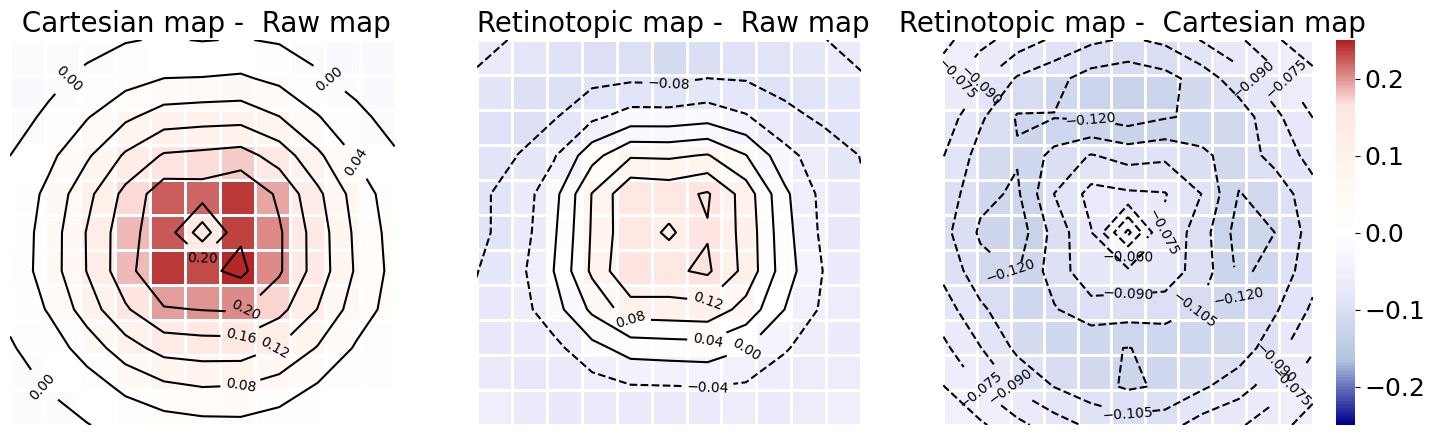

In [7]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])

map = cart_map-raw_map
CS = axs[0].contour(X, Y, map, colors='black' )
axs[0].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-.25, vmax=.25, ax=axs[0], annot_kws={"fontsize":9})
axs[0].set_title(' Cartesian map -  Raw map', size = 20)
axs[0].set_xticks([])
axs[0].set_yticks([])


map = ret_map-raw_map
CS = axs[1].contour(X, Y, map, colors='black' )
axs[1].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=axs[1],cbar = False, vmin=-.25, vmax=.25, annot_kws={"fontsize":9})
axs[1].set_title(' Retinotopic map -  Raw map', size = 20)
axs[1].set_xticks([])
axs[1].set_yticks([])


cmap_bis = matplotlib.colors.LinearSegmentedColormap.from_list("", ["darkblue",  "lightsteelblue", "lavender", "white"])

map = ret_map-cart_map
CS = axs[2].contour(X, Y, map, colors='black' )
axs[2].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = True, vmin=-.25, vmax=0.25, ax=axs[2], annot_kws={"fontsize":9})
axs[2].set_title(' Retinotopic map -  Cartesian map', size = 20)
axs[2].set_xticks([])
axs[2].set_yticks([])

if False:
    to_save(fig, 'fig-mean_map_Imagenet_diff_paper')

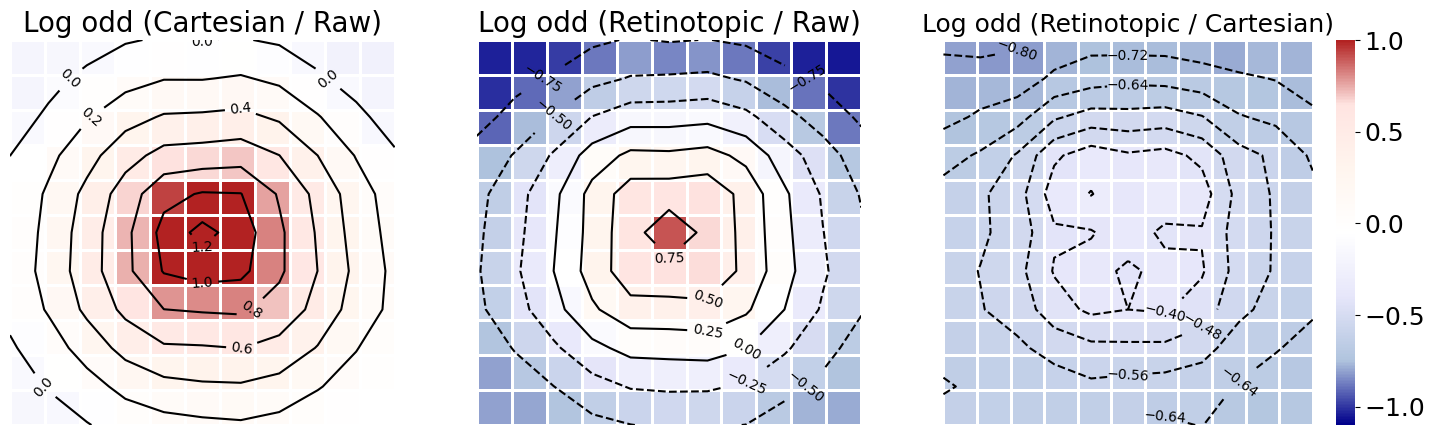

In [9]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])


#map = cart_map-raw_map
map = get_odd_ratio(cart_map, raw_map)
CS = axs[0].contour(X, Y, map, colors='black' )
axs[0].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-1, vmax=1, ax=axs[0], annot_kws={"fontsize":9})
axs[0].set_title('Log odd (Cartesian / Raw)', size = 20)
axs[0].set_xticks([])
axs[0].set_yticks([])


#map = ret_map-raw_map
map = get_odd_ratio(ret_map, raw_map)
CS = axs[1].contour(X, Y, map, colors='black' )
axs[1].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=axs[1], cbar = False, vmin=-1, vmax=1, annot_kws={"fontsize":9})
axs[1].set_title('Log odd (Retinotopic / Raw)', size = 20)
axs[1].set_xticks([])
axs[1].set_yticks([])

#map = ret_map-cart_map
map = get_odd_ratio(ret_map, cart_map)
CS = axs[2].contour(X, Y, map, colors='black')
axs[2].clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', vmin=1, vmax=-1, ax=axs[2], annot_kws={"fontsize":9})
axs[2].set_title('Log odd (Retinotopic / Cartesian)', size = 18)
axs[2].set_xticks([])
axs[2].set_yticks([])

if False:
    to_save(fig, 'fig-mean_map_Imagenet_odd_paper')

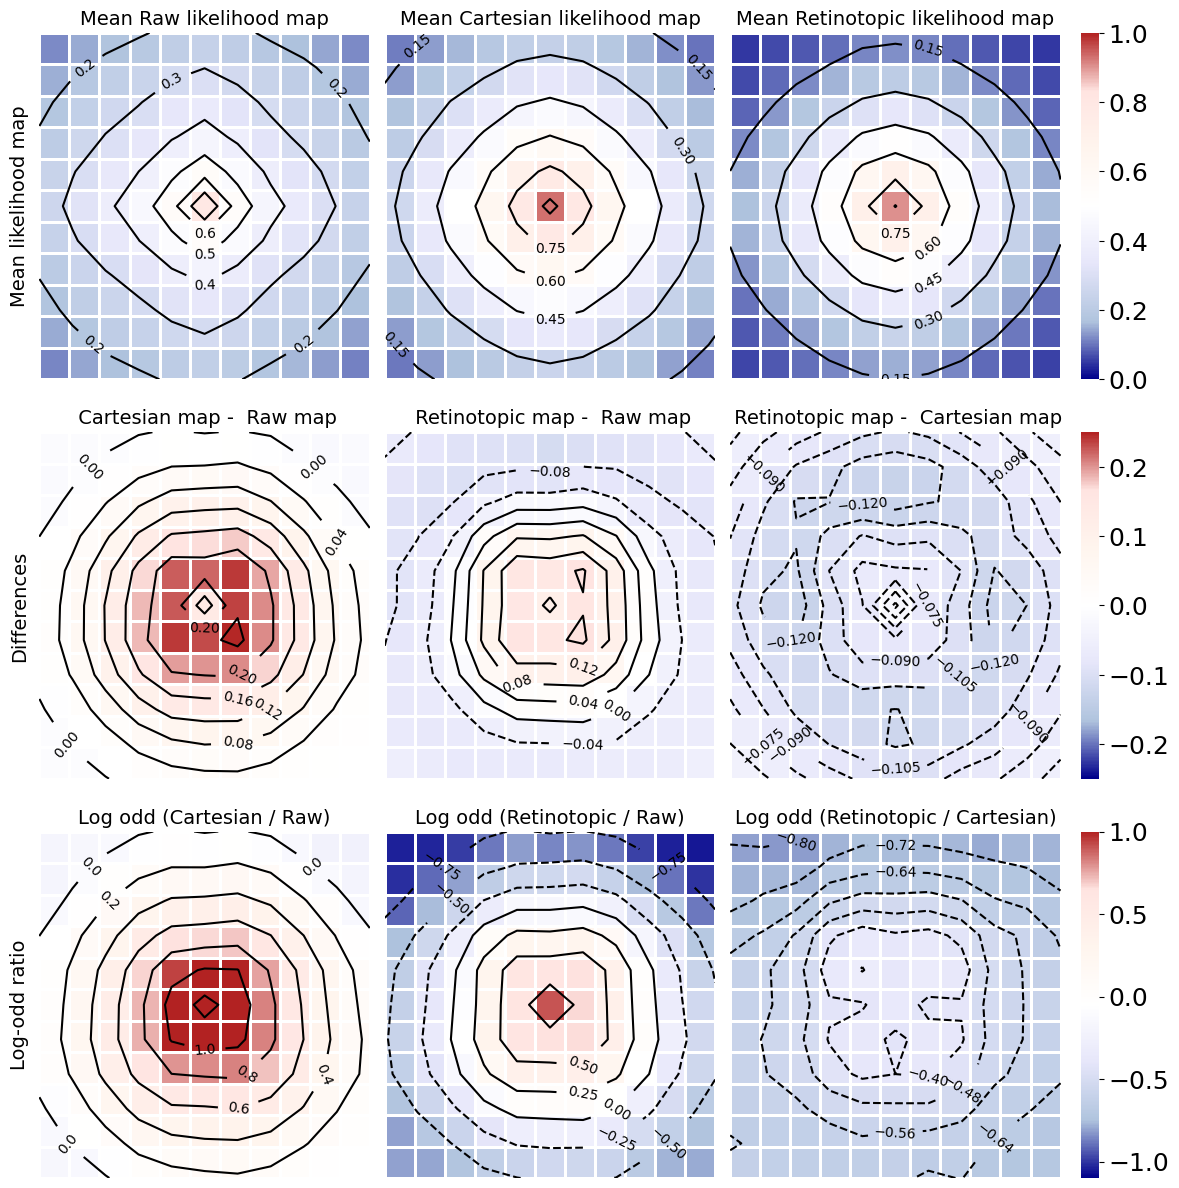

In [48]:

fig, axs = plt.subplots(3, 3, figsize=(12, 12), width_ratios=[1, 1, 1.25])
axs = axs.flat
i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']

for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model]
    title_mod = all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap=cmap, vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax, annot_kws={"fontsize":10})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'Mean {title_mod} likelihood map', size = fontsize)
    ax.set_xticks([])
    ax.set_yticks([])
    axs[0].set_ylabel(f"Mean likelihood map", size=fontsize)

i_model += 1 
ax = axs[i_model]
map = cart_map-raw_map
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-.25, vmax=.25, ax=ax, annot_kws={"fontsize":10})
ax.set_title(' Cartesian map -  Raw map', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel(f"Differences", size=fontsize)


i_model += 1
ax = axs[i_model] 
map = ret_map-raw_map
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=ax ,cbar = False, vmin=-.25, vmax=.25, annot_kws={"fontsize":10})
ax.set_title(' Retinotopic map -  Raw map', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])


i_model += 1
ax = axs[i_model]
map = ret_map-cart_map
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = True, vmin=-.25, vmax=0.25, ax=ax, annot_kws={"fontsize":10})
ax.set_title(' Retinotopic map -  Cartesian map', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])

i_model += 1
ax = axs[i_model]
map = get_odd_ratio(cart_map, raw_map)
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', cbar = False, vmin=-1, vmax=1, ax=ax, annot_kws={"fontsize":10})
ax.set_title('Log odd (Cartesian / Raw)', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel(f"Log-odd ratio", size=fontsize)


i_model += 1
ax = axs[i_model]
map = get_odd_ratio(ret_map, raw_map)
CS = ax.contour(X, Y, map, colors='black' )
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', ax=ax, cbar = False, vmin=-1, vmax=1, annot_kws={"fontsize":10})
ax.set_title('Log odd (Retinotopic / Raw)', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])

i_model += 1
ax = axs[i_model]
map = get_odd_ratio(ret_map, cart_map)
CS = ax.contour(X, Y, map, colors='black')
ax.clabel(CS, inline=True, fontsize=10)
sns.heatmap(map, linewidth = 1 , annot = False, cmap=cmap, fmt='.1g', vmin=1, vmax=-1, ax=ax, annot_kws={"fontsize":10})
ax.set_title('Log odd (Retinotopic / Cartesian)', size = fontsize)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

if True:
    to_save(fig, 'fig-complete_mean_maps_paper')